# ORB Feature Matching: Essential Validation & Enhancement Study

This notebook evaluates four algorithm-specific ORB configurations on the 139-image validation split. Every configuration uses the predetermined shared preprocessing pipeline: 3×3 Gaussian denoising followed by CLAHE (clip limit 2.0, tile grid 8×8). Only ORB-specific matching, clustering, and area-filtering settings differ. The highest aggregate F1-score at IoU 0.50 determines the frozen configuration. No calibration candidate is included.

### Enhancement Strategy:
1. **Validation reference configuration**: Individual fixed-radius keypoint boxes without clustering or area filtering; shared Gaussian+CLAHE preprocessing remains enabled.
2. **Point Clustering Mask (`merge_points=True`)**: Renders anomaly keypoint coordinates onto a binary mask and merges them via contour extraction.
3. **Radius & Filter Tuning**: Balances clustering radius and eliminates isolated single-point false alarms.


In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'validation' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from algorithms.common import load_image
from algorithms.evaluation import evaluate_boxes, parse_voc_boxes
from algorithms.orb import detect_orb
from algorithms.preprocessing import build_preprocessing_config

plt.rcParams['figure.dpi'] = 110
print(f'Project Root: {PROJECT_ROOT}')

# Smart auto-run fallback: auto-compute benchmark if outputs/metrics CSV is missing
res_csv = PROJECT_ROOT / 'outputs' / 'metrics' / 'essential_validation_comparison.csv'
if not res_csv.exists():
    print('⚠️ Validation metrics CSV not found. Auto-running validation benchmark on 139 validation images...')
    from scripts.evaluation.run_essential_validation import main as run_benchmark
    run_benchmark()
    print('✅ Benchmark successfully generated!')


Project Root: C:\Users\jieer\Documents\GitHub\pcb-defects-inspection


## 1. Essential Validation Results (4 Core Configurations)


In [4]:
df = pd.read_csv(res_csv)
df['description'] = df['description'].replace({'Raw discrete keypoint boxes (Hamming=60, R=35, Merge=False)': 'Validation reference: shared preprocessing + discrete keypoint boxes (Hamming=60, R=35, Merge=False)'})
orb_df = df[df['algorithm'] == 'ORB'][['combination_id', 'description', 'precision', 'recall', 'f1_score', 'mean_runtime_ms']]
display(orb_df)


,combination_id,description,precision,recall,f1_score,mean_runtime_ms
12,ORB-Baseline,Validation reference: shared preprocessing + d...,0.002266,0.251291,0.004492,640.582660
13,ORB-Merged-R35,"Mask-clustered keypoint contours (Hamming=60, ...",0.002196,0.039587,0.004161,660.457563
14,ORB-Merged-R20,"Compact mask-clustered contours (Hamming=40, R...",0.003115,0.122203,0.006075,645.895854
15,ORB-Best-Area300,Optimal compact clustering with noise filter (...,0.003115,0.122203,0.006075,556.631940


## 2. Visual Comparison of ORB Configurations

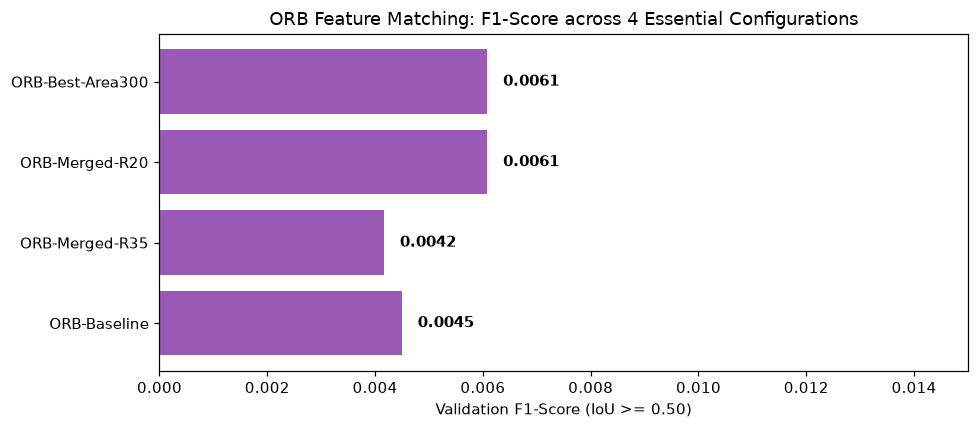

In [5]:
plt.figure(figsize=(9, 4))
plt.barh(orb_df['combination_id'], orb_df['f1_score'], color='#9b59b6')
plt.xlabel('Validation F1-Score (IoU >= 0.50)')
plt.title('ORB Feature Matching: F1-Score across 4 Essential Configurations')
plt.xlim(0, 0.015)
for i, v in enumerate(orb_df['f1_score']):
    plt.text(v + 0.0003, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()
